# Module 1 Homework: Docker & SQL

In this homework we'll prepare the environment and practice
Docker and SQL

When submitting your homework, you will also need to include
a link to your GitHub repository or other public code-hosting
site.

This repository should contain the code for solving the homework. 

When your solution has SQL or shell commands and not code
(e.g. python files) file format, include them directly in
the README file of your repository.

## Question 1. Understanding docker first run 

Run docker with the `python:3.12.8` image in an interactive mode, use the entrypoint `bash`.

What's the version of `pip` in the image?

- 24.3.1
- 24.2.1
- 23.3.1
- 23.2.1

```
docker run -it python:3.12.8 /bin/bash
Unable to find image 'python:3.12.8' locally
3.12.8: Pulling from library/python
86f9cc2995ad: Download complete 
c80762877ac5: Download complete 
c980de82d033: Download complete 
Digest: sha256:2e726959b8df5cd9fd95a4cbd6dcd23d8a89e750e9c2c5dc077ba56365c6a925
Status: Downloaded newer image for python:3.12.8

root@c141ba08f103:/# pip -V
pip 24.3.1 from /usr/local/lib/python3.12/site-packages/pip (python 3.12)

```

**Answer is 24.3.1**

In [1]:
from IPython.display import Image

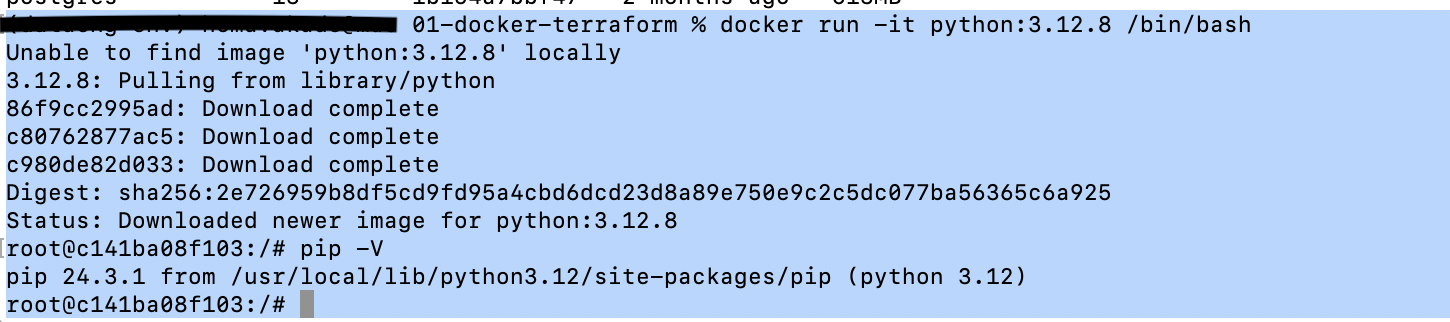

In [3]:
Image(filename='homework_Q1.png') 

## Question 2. Understanding Docker networking and docker-compose

Given the following `docker-compose.yaml`, what is the `hostname` and `port` that **pgadmin** should use to connect to the postgres database?

```yaml
services:
  db:
    container_name: postgres
    image: postgres:17-alpine
    environment:
      POSTGRES_USER: 'postgres'
      POSTGRES_PASSWORD: 'postgres'
      POSTGRES_DB: 'ny_taxi'
    ports:
      - '5433:5432'
    volumes:
      - vol-pgdata:/var/lib/postgresql/data

  pgadmin:
    container_name: pgadmin
    image: dpage/pgadmin4:latest
    environment:
      PGADMIN_DEFAULT_EMAIL: "pgadmin@pgadmin.com"
      PGADMIN_DEFAULT_PASSWORD: "pgadmin"
    ports:
      - "8080:80"
    volumes:
      - vol-pgadmin_data:/var/lib/pgadmin  

volumes:
  vol-pgdata:
    name: vol-pgdata
  vol-pgadmin_data:
    name: vol-pgadmin_data
```

- postgres:5433
- localhost:5432
- db:5433
- postgres:5432
- db:5432

If there are more than one answers, select only one of them

**Answer is**

**postgres:5432**

##  Prepare Postgres

Run Postgres and load data as shown in the videos
We'll use the green taxi trips from October 2019:

```bash
wget https://github.com/DataTalksClub/nyc-tlc-data/releases/download/green/green_tripdata_2019-10.csv.gz
```

You will also need the dataset with zones:

```bash
wget https://github.com/DataTalksClub/nyc-tlc-data/releases/download/misc/taxi_zone_lookup.csv
```

Download this data and put it into Postgres.

You can use the code from the course. It's up to you whether
you want to use Jupyter or a python script.

In [7]:
from dotenv import load_dotenv
from sqlalchemy import create_engine
# env file contains sensitive data
import os
import pandas as pd
from time import time

load_dotenv()

POSTGRES_URI = os.getenv('POSTGRES_URI')
engine = create_engine(POSTGRES_URI)

green_trips_df = pd.read_csv("./homework_data/green_tripdata_2019-10.csv", nrows=5)
print(green_trips_df.info())
green_trips_df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
green_trips_df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
# Create an empty table
green_trips_df.head(0).to_sql(name="green_taxi_data", con=engine, if_exists='replace')

In [14]:
from time import time
iter_chunk = 100000
green_trips_df_iter = pd.read_csv("./homework_data/green_tripdata_2019-10.csv", iterator=True, chunksize=iter_chunk)
brk = 1
while brk:
    try:
        print(f"Begin processing {iter_chunk} chunk of green trips data")
        start_time = time()
        df = next(green_trips_df_iter)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.to_sql(name="green_taxi_data", con=engine, if_exists='append')
    except StopIteration:
        brk = 0
print(f'Time to insert all records {time() - start_time}')

Begin processing 100000 chunk of green trips data
Begin processing 100000 chunk of green trips data
Begin processing 100000 chunk of green trips data
Begin processing 100000 chunk of green trips data


/var/folders/lb/yq7g9ff95dgbw326m64dkw700000gn/T/ipykernel_35599/4079191590.py:9: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = next(green_trips_df_iter)


Begin processing 100000 chunk of green trips data
Begin processing 100000 chunk of green trips data
Time to insert all records 0.00012922286987304688


## Question 3. Trip Segmentation Count

During the period of October 1st 2019 (inclusive) and November 1st 2019 (exclusive), how many trips, **respectively**, happened:
1. Up to 1 mile
2. In between 1 (exclusive) and 3 miles (inclusive),
3. In between 3 (exclusive) and 7 miles (inclusive),
4. In between 7 (exclusive) and 10 miles (inclusive),
5. Over 10 miles 

Answers:

- 104,802;  197,670;  110,612;  27,831;  35,281
- 104,802;  198,924;  109,603;  27,678;  35,189
- 104,793;  201,407;  110,612;  27,831;  35,281
- 104,793;  202,661;  109,603;  27,678;  35,189
- 104,838;  199,013;  109,645;  27,688;  35,202

----


*According to data dictionary,* 
- *Trip_distance  : The elapsed trip distance in miles reported by the taximeter.* 
- *lpep_pickup_datetime : The date and time when the meter was engaged.*
- *lpep_dropoff_datetime : The date and time when the meter was disengaged.*


1. **Up to 1 mile**
   
```sql

SELECT
	COUNT(1) TRIPS_COUNT
FROM
	GREEN_TAXI_DATA GT
WHERE
	TRIP_DISTANCE<=1 AND
	(CAST(GT.lpep_dropoff_datetime AS DATE) >= '2019-10-01' 
	AND CAST(GT.lpep_dropoff_datetime AS DATE) < '2019-11-01')

```
**Answer : 104,802**


2. **In between 1 (exclusive) and 3 miles (inclusive)**

```sql

SELECT
	COUNT(1) TRIPS_COUNT
FROM
	GREEN_TAXI_DATA GT
WHERE
	(
		TRIP_DISTANCE > 1.0
		AND TRIP_DISTANCE <= 3.0
	)
	AND (
		CAST(GT.LPEP_DROPOFF_DATETIME AS DATE) >= '2019-10-01'
		AND CAST(GT.LPEP_DROPOFF_DATETIME AS DATE) < '2019-11-01'
	)
    
```

**Answer : 198,924**

3. **In between 3 (exclusive) and 7 miles (inclusive)**

```sql

SELECT
	COUNT(1) TRIPS_COUNT
FROM
	GREEN_TAXI_DATA GT
WHERE
	(
		TRIP_DISTANCE > 3.0
		AND TRIP_DISTANCE <= 7.0
	)
	AND (
		CAST(GT.LPEP_DROPOFF_DATETIME AS DATE) >= '2019-10-01'
		AND CAST(GT.LPEP_DROPOFF_DATETIME AS DATE) < '2019-11-01'
	)
```

**Answer : 109,603**
   
4. **In between 7 (exclusive) and 10 miles (inclusive)**

```sql

SELECT
	COUNT(1) TRIPS_COUNT
FROM
	GREEN_TAXI_DATA GT
WHERE
	(
		TRIP_DISTANCE > 7.0
		AND TRIP_DISTANCE <= 10.0
	)
	AND (
		CAST(GT.LPEP_DROPOFF_DATETIME AS DATE) >= '2019-10-01'
		AND CAST(GT.LPEP_DROPOFF_DATETIME AS DATE) < '2019-11-01'
	)
```

**Answer : 27678**

5. **Over 10 miles**


```sql

SELECT
	COUNT(1) TRIPS_COUNT
FROM
	GREEN_TAXI_DATA GT
WHERE
	(
		 TRIP_DISTANCE > 10.0
	)
	AND (
		CAST(GT.LPEP_DROPOFF_DATETIME AS DATE) >= '2019-10-01'
		AND CAST(GT.LPEP_DROPOFF_DATETIME AS DATE) < '2019-11-01'
	)
```
**Answer : 35189**


## Question 4. Longest trip for each day

Which was the pick up day with the longest trip distance?
Use the pick up time for your calculations.

Tip: For every day, we only care about one single trip with the longest distance. 

- 2019-10-11
- 2019-10-24
- 2019-10-26
- 2019-10-31

1.
```sql
SELECT
	MAX(TRIP_DISTANCE) longest_trip_distance
FROM
	GREEN_TAXI_DATA GT
WHERE
	CAST(GT.LPEP_PICKUP_DATETIME AS DATE) = '2019-10-11';
```
**Answer 95.78 miles**

2.
```sql
SELECT
	MAX(TRIP_DISTANCE) longest_trip_distance
FROM
	GREEN_TAXI_DATA GT
WHERE
	CAST(GT.LPEP_PICKUP_DATETIME AS DATE) = '2019-10-24';
```
**Answer 90.75 miles**

3.
```sql
SELECT
	MAX(TRIP_DISTANCE) longest_trip_distance
FROM
	GREEN_TAXI_DATA GT
WHERE
	CAST(GT.LPEP_PICKUP_DATETIME AS DATE) = '2019-10-26';
```
**Answer 91.56 miles**

4.
```sql
SELECT
	MAX(TRIP_DISTANCE) longest_trip_distance
FROM
	GREEN_TAXI_DATA GT
WHERE
	CAST(GT.LPEP_PICKUP_DATETIME AS DATE) = '2019-10-31';
```
**Answer 515.89 miles**



## Question 5. Three biggest pickup zones

Which were the top pickup locations with over 13,000 in
`total_amount` (across all trips) for 2019-10-18?

Consider only `lpep_pickup_datetime` when filtering by date.
 
- East Harlem North, East Harlem South, Morningside Heights
- East Harlem North, Morningside Heights
- Morningside Heights, Astoria Park, East Harlem South
- Bedford, East Harlem North, Astoria Park

```sql
select z."Zone" trip_zone 
from
(SELECT
	GTI."PULocationID" PICKUP_LOC_ID,
	COUNT(1) TRIP_COUNT_BY_PICKUP_LOC,
	SUM(GTI.TOTAL_AMOUNT) TOTAL_AMT_BY_PICKUP_LOC
FROM
	GREEN_TAXI_DATA GTI
WHERE
	GTI."PULocationID" IS NOT NULL
	AND CAST(GTI.LPEP_PICKUP_DATETIME AS DATE) = '2019-10-18'
GROUP BY
	PICKUP_LOC_ID
having SUM(GTI.TOTAL_AMOUNT) > 13000.0) as gt
inner join zones z on gt.PICKUP_LOC_ID = Z."LocationID"
ORDER BY
	gt.TRIP_COUNT_BY_PICKUP_LOC DESC

```

Answer is **East Harlem North, East Harlem South, Morningside Heights with 1236, 1101, 764 count of trips respectively**


## Question 6. Largest tip

For the passengers picked up in October 2019 in the zone
named "East Harlem North" which was the drop off zone that had
the largest tip?

Note: it's `tip` , not `trip`

We need the name of the zone, not the ID.

- Yorkville West
- JFK Airport
- East Harlem North
- East Harlem South

## Terraform

In this section homework we'll prepare the environment by creating resources in GCP with Terraform.

In your VM on GCP/Laptop/GitHub Codespace install Terraform. 
Copy the files from the course repo
[here](../../../01-docker-terraform/1_terraform_gcp/terraform) to your VM/Laptop/GitHub Codespace.

Modify the files as necessary to create a GCP Bucket and Big Query Dataset.

## Question 7. Terraform Workflow

Which of the following sequences, **respectively**, describes the workflow for: 
1. Downloading the provider plugins and setting up backend,
2. Generating proposed changes and auto-executing the plan
3. Remove all resources managed by terraform`

Answers:
- terraform import, terraform apply -y, terraform destroy
- teraform init, terraform plan -auto-apply, terraform rm
- terraform init, terraform run -auto-approve, terraform destroy
- terraform init, terraform apply -auto-approve, terraform destroy
- terraform import, terraform apply -y, terraform rm

## Submitting the solutions

* Form for submitting: https://courses.datatalks.club/de-zoomcamp-2025/homework/hw1